# Clickbait Binary Classification Pilot

## 1. Project Goal

Build a supervised NLP classifier that predicts whether a news headline or teaser is `clickbait` or `non_clickbait`.

This first stage detects clickbait style, not factual correctness. Spoiler generation is a possible later extension and is not included here.

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

import clickbait_pipeline as cp

pd.set_option("display.max_colwidth", 120)
FIGURES_DIR = Path("outputs/figures")

## Run Pipeline

The reusable implementation lives in `clickbait_pipeline.py`. This notebook only orchestrates the run and presents the results.

In [2]:
webis_result = cp.train_evaluate_webis()

best_model = webis_result["best_model"]
best_model_name = webis_result["best_model_name"]

kaggle, kaggle_eval = cp.evaluate_external_kaggle(best_model)
kaggle_analysis = cp.prediction_analysis_table(best_model, kaggle)
features = cp.top_features(webis_result["models"]["logistic_regression"], top_n=20)
ngram_features = cp.top_features_by_ngram(webis_result["models"]["logistic_regression"], top_n=15)

saved_figures = cp.save_standard_figures(
    webis=webis_result["webis"],
    kaggle=kaggle,
    webis_metrics=webis_result["metrics"],
    webis_confusion_matrix=webis_result["evaluation_details"][best_model_name]["confusion_matrix"],
    kaggle_confusion_matrix=kaggle_eval["confusion_matrix"],
    threshold_report=webis_result["threshold_report"],
    features_df=features,
    kaggle_analysis=kaggle_analysis,
    ngram_features_df=ngram_features,
)

best_model_name, webis_result["threshold"], len(saved_figures)

('logistic_regression', 0.3, 16)

## 2. Dataset Summary

In [3]:
combined = pd.concat([webis_result["webis"], kaggle], ignore_index=True)
summary = cp.eda_summary(combined)

display(summary["dataset_size"])
display(summary["dataset_counts"])
display(summary["label_by_dataset"])
display(summary["missing"])
display(summary["duplicate_text_count"])

,rows,columns
0,51538,7


,dataset,count
0,kaggle,32000
1,webis,19538


label_binary,0,1
dataset,,
kaggle,16001,15999
webis,10842,8696


,column,missing_count
0,dataset,0
1,id,0
2,text_original,0
3,text_clean,0
4,label_raw,0
5,score_raw,0
6,label_binary,0


,duplicate_text_count
0,416


## 3. Webis Threshold Comparison

The Webis score threshold is selected by a simple data-driven rule: avoid extreme class imbalance, keep enough samples in both classes, then prefer the threshold with the best minority/majority balance.

,threshold,n_rows,clickbait_count,non_clickbait_count,clickbait_rate,non_clickbait_rate,minority_count,class_balance
0,0.3,19538,8696,10842,0.445081,0.554919,8696,0.802066
1,0.4,19538,5927,13611,0.303358,0.696642,5927,0.435457
2,0.5,19538,4740,14798,0.242604,0.757396,4740,0.320314
3,0.6,19538,2953,16585,0.151141,0.848859,2953,0.178052
4,0.7,19538,2121,17417,0.108558,0.891442,2121,0.121778
5,0.8,19538,1005,18533,0.051438,0.948562,1005,0.054228


Selected threshold: 0.3


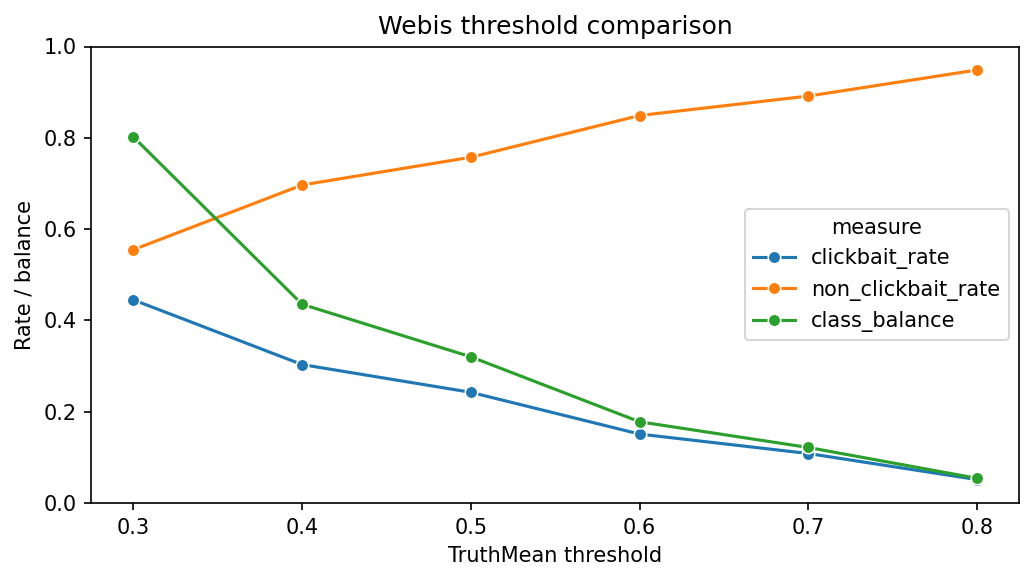

In [4]:
display(webis_result["threshold_report"])
print(f"Selected threshold: {webis_result['threshold']}")
display(Image(filename=str(FIGURES_DIR / "threshold_comparison.png")))

## 4. Label Distributions

,label_binary,count,percentage
0,0,26843,52.083899
1,1,24695,47.916101


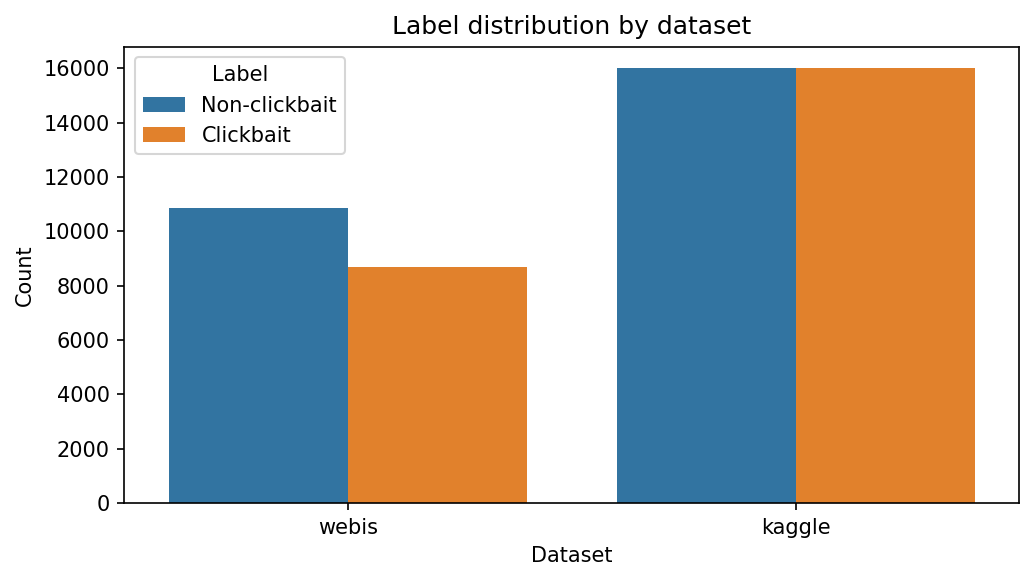

In [5]:
display(cp.label_distribution(combined))
display(Image(filename=str(FIGURES_DIR / "label_distribution_by_dataset.png")))

## 5. Webis Model Comparison

,model,accuracy,precision,recall,f1,macro_f1,roc_auc
0,logistic_regression,0.714176,0.674523,0.691202,0.682761,0.711345,0.772885
1,naive_bayes,0.697288,0.706845,0.546291,0.616283,0.683168,0.767387
2,linear_svm,0.685773,0.641082,0.667625,0.654085,0.683114,0.737376
3,majority_baseline,0.555015,0.000000,0.000000,0.000000,0.356920,0.500000


Best model by macro F1: logistic_regression


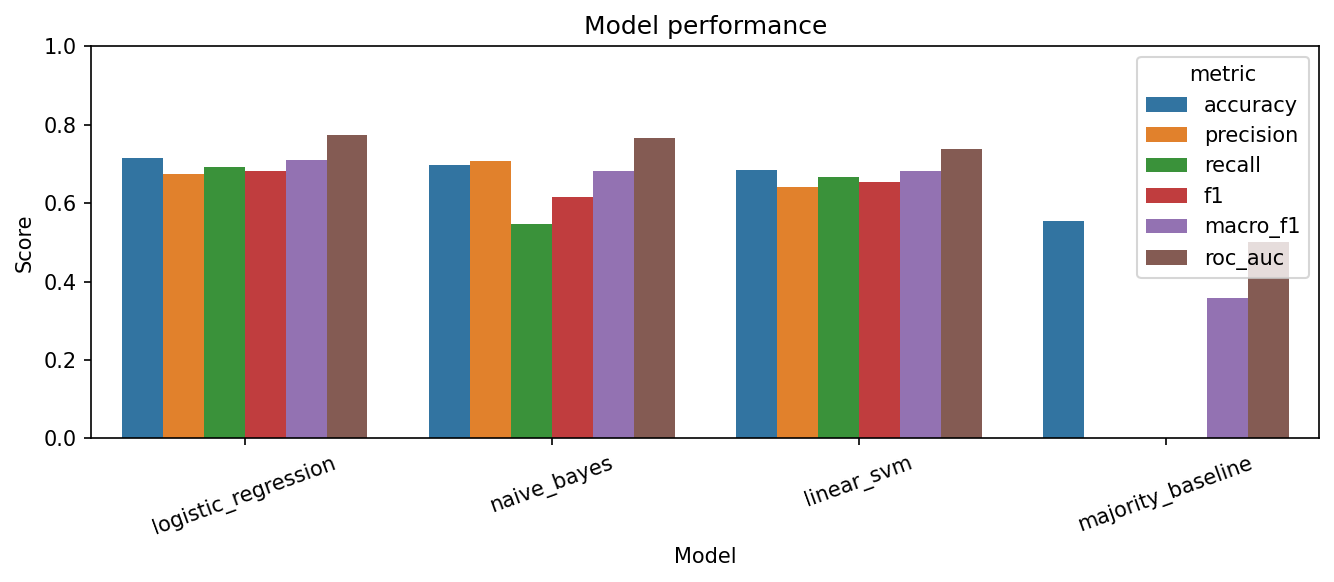

In [6]:
display(webis_result["metrics"])
print(f"Best model by macro F1: {best_model_name}")
display(Image(filename=str(FIGURES_DIR / "model_comparison.png")))

## 6. Best Model Confusion Matrix

,pred_non_clickbait,pred_clickbait
true_non_clickbait,1589,580
true_clickbait,537,1202


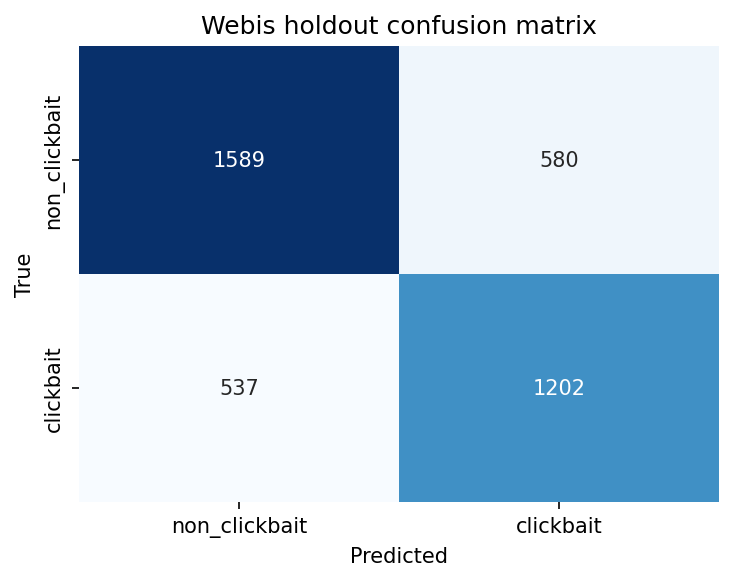

In [7]:
display(pd.DataFrame(
    webis_result["evaluation_details"][best_model_name]["confusion_matrix"],
    index=["true_non_clickbait", "true_clickbait"],
    columns=["pred_non_clickbait", "pred_clickbait"],
))
display(Image(filename=str(FIGURES_DIR / "webis_holdout_confusion_matrix.png")))

## 7. Kaggle External Test Results

,accuracy,precision,recall,f1,macro_f1,roc_auc
0,0.837094,0.803182,0.892993,0.84571,0.836584,0.924108


,pred_non_clickbait,pred_clickbait
true_non_clickbait,12500,3501
true_clickbait,1712,14287


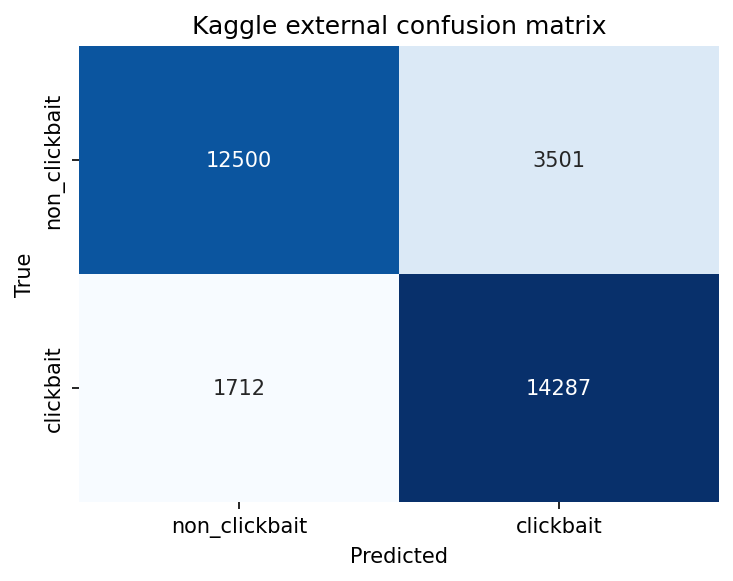

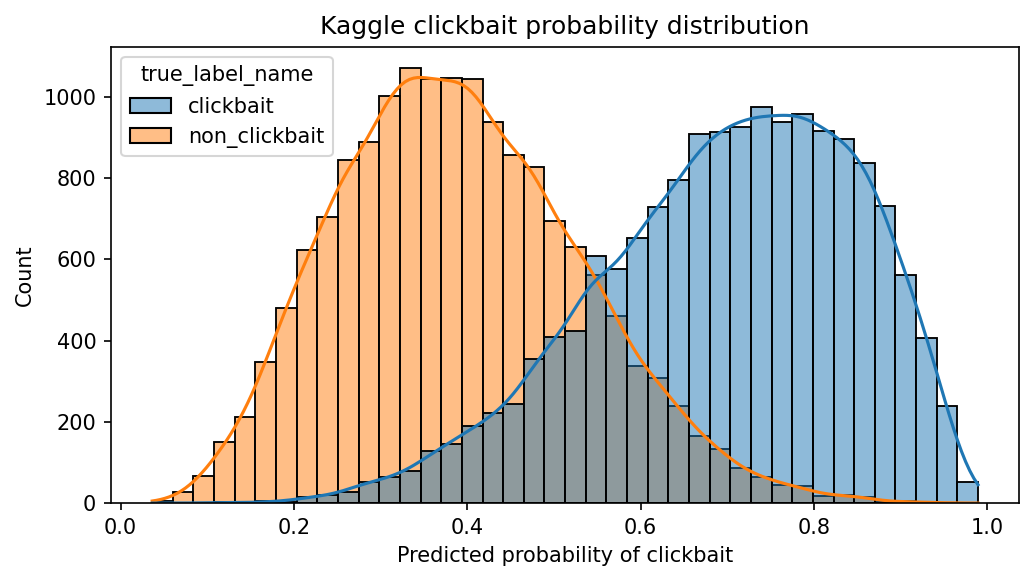

In [8]:
kaggle_metrics = pd.DataFrame([{
    key: kaggle_eval.get(key)
    for key in ["accuracy", "precision", "recall", "f1", "macro_f1", "roc_auc"]
}])
display(kaggle_metrics)
display(pd.DataFrame(
    kaggle_eval["confusion_matrix"],
    index=["true_non_clickbait", "true_clickbait"],
    columns=["pred_non_clickbait", "pred_clickbait"],
))
display(Image(filename=str(FIGURES_DIR / "kaggle_external_confusion_matrix.png")))
display(Image(filename=str(FIGURES_DIR / "kaggle_confidence_distribution.png")))

## 8. Top TF-IDF Features

The overall feature table is kept for continuity. The bigram and trigram slices are more interpretable for clickbait phrasing patterns.

,feature,weight,ngram_length,class_label
0,things,3.632301,1,clickbait
1,best,3.245990,1,clickbait
2,know,2.708852,1,clickbait
3,ways,2.689226,1,clickbait
4,quiz,1.976140,1,clickbait
5,need,1.972828,1,clickbait
6,happens,1.949082,1,clickbait
7,hilarious,1.937520,1,clickbait
8,tips,1.929910,1,clickbait
9,advice,1.886588,1,clickbait


,feature,weight,ngram_length,class_label
20,says,-3.564592,1,non_clickbait
21,ban,-2.603683,1,non_clickbait
22,dies,-2.560654,1,non_clickbait
23,trump,-2.471692,1,non_clickbait
24,amid,-2.445612,1,non_clickbait
25,china,-2.255835,1,non_clickbait
26,talks,-2.100807,1,non_clickbait
27,million,-2.069936,1,non_clickbait
28,officials,-2.050004,1,non_clickbait
29,reportedly,-1.984978,1,non_clickbait


Top bigram features


,feature,weight,ngram_length,class_label
30,need know,1.062505,2,clickbait
31,anti trump,1.039131,2,clickbait
32,entertainment news,0.905577,2,clickbait
33,social media,0.883391,2,clickbait
34,arrested airport,0.880858,2,clickbait
35,new year,0.866637,2,clickbait
36,facebook live,0.837861,2,clickbait
37,trump presidency,0.834645,2,clickbait
38,100 000,0.793722,2,clickbait
39,stories day,0.789593,2,clickbait


Top trigram features


,feature,weight,ngram_length,class_label
60,new york city,0.594806,3,clickbait
61,profit trump inflation,0.569602,3,clickbait
62,entertainment stories day,0.554761,3,clickbait
63,entertainment news day,0.536359,3,clickbait
64,briefing need know,0.530291,3,clickbait
65,president trump russia,0.484308,3,clickbait
66,supreme court nominee,0.467921,3,clickbait
67,16 year old,0.456591,3,clickbait
68,new jersey town,0.454941,3,clickbait
69,waking night natural,0.452703,3,clickbait


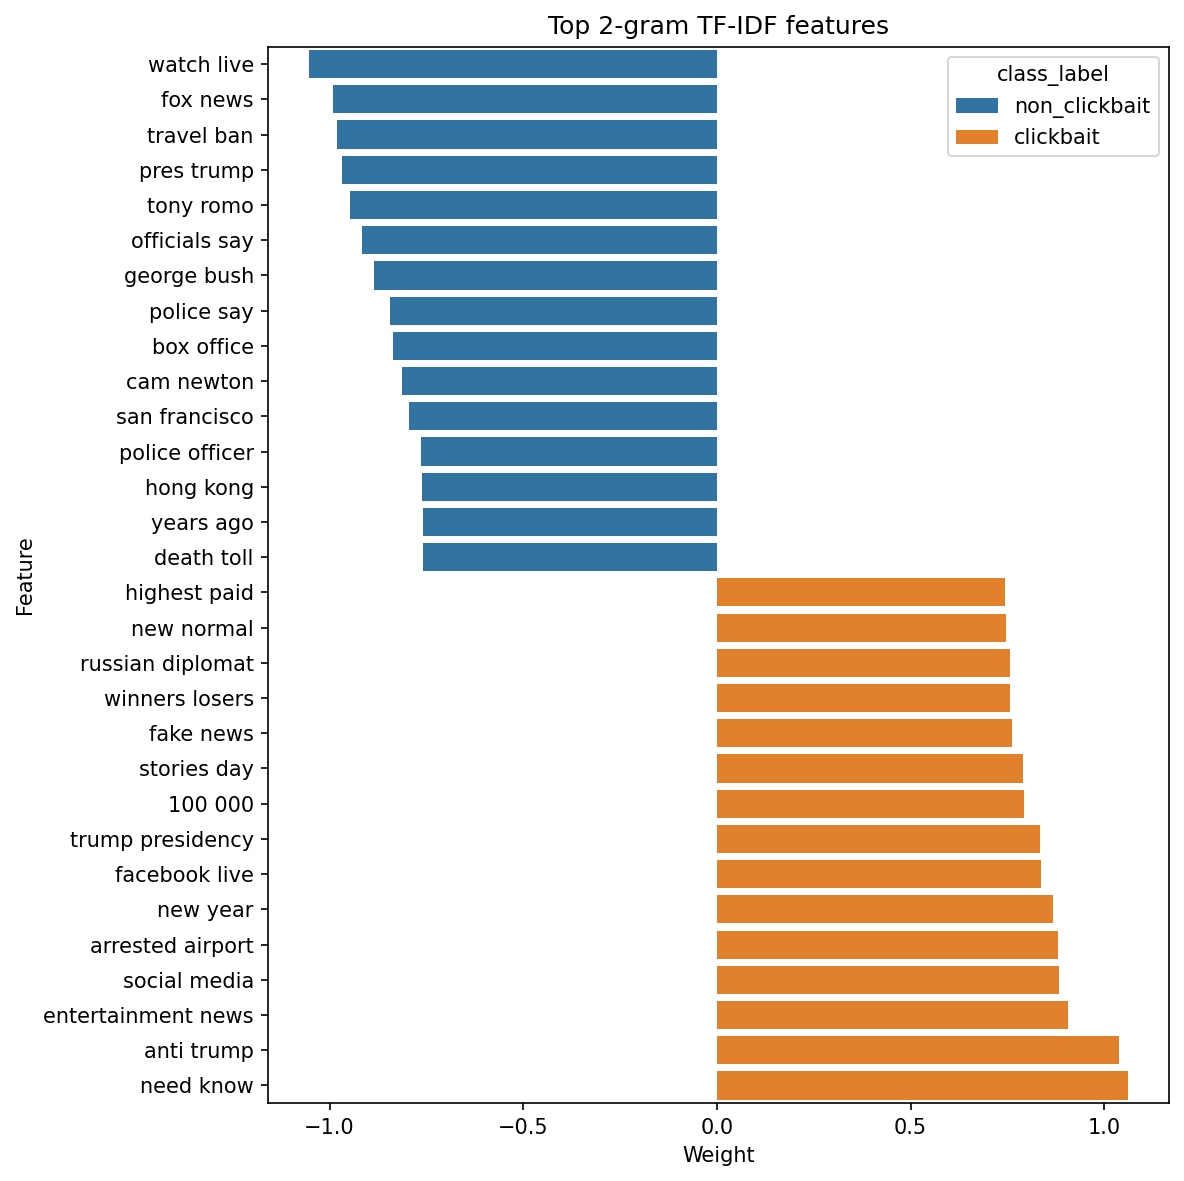

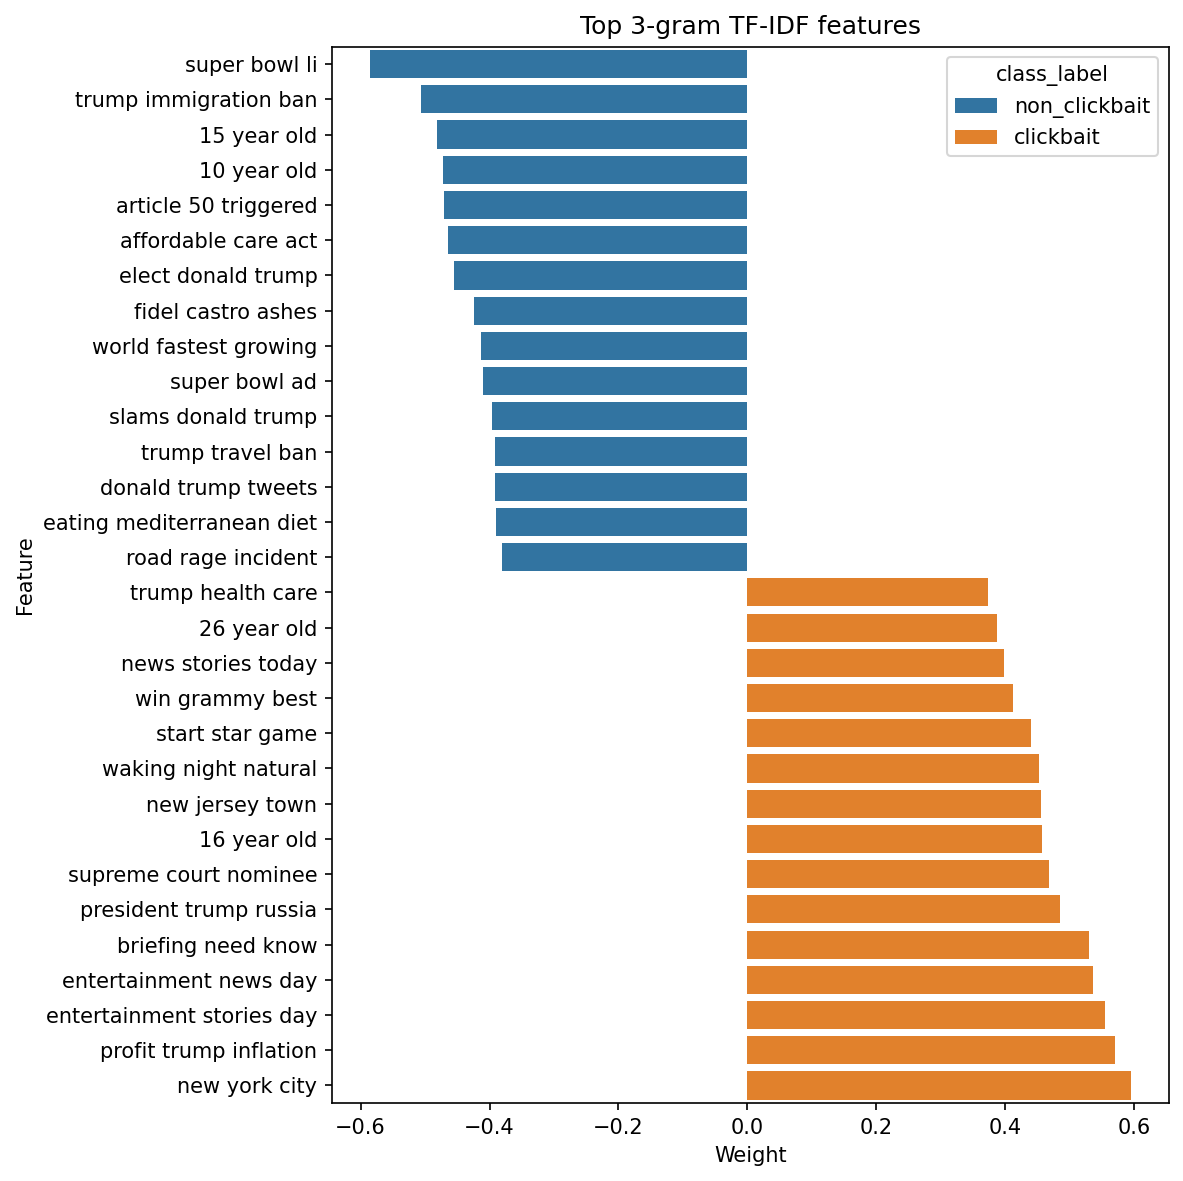

In [9]:
display(features[features["class_label"] == "clickbait"].head(10))
display(features[features["class_label"] == "non_clickbait"].head(10))

print("Top bigram features")
display(ngram_features[ngram_features["ngram_length"] == 2].head(20))

print("Top trigram features")
display(ngram_features[ngram_features["ngram_length"] == 3].head(20))

display(Image(filename=str(FIGURES_DIR / "top_bigram_features.png")))
display(Image(filename=str(FIGURES_DIR / "top_trigram_features.png")))

## 9. Selected Error Examples

In [10]:
error_columns = [
    "id",
    "text_original",
    "true_label_name",
    "predicted_label_name",
    "predicted_probability",
]

print("False positives")
display(cp.false_positives(kaggle_analysis)[error_columns].head(8))

print("False negatives")
display(cp.false_negatives(kaggle_analysis)[error_columns].head(8))

print("High-confidence errors")
display(cp.high_confidence_errors(kaggle_analysis, n=8)[error_columns])

print("Low-confidence predictions")
display(cp.low_confidence_predictions(kaggle_analysis, n=8)[error_columns])

False positives


,id,text_original,true_label_name,predicted_label_name,predicted_probability
15999,kaggle_15999,Bill Changing Credit Card Rules Is Sent to Obama With Gun Measure Included,non_clickbait,clickbait,0.661715
16000,kaggle_16000,"In Hollywood, the Easy-Money Generation Toughens Up",non_clickbait,clickbait,0.611402
16007,kaggle_16007,"US Highway Administration releases interim report on Boston's Big Dig: press release claims tunnel safe, but report ...",non_clickbait,clickbait,0.516493
16020,kaggle_16020,"With Fine Print, the Rollout Dazzles This Time",non_clickbait,clickbait,0.520812
16027,kaggle_16027,Credit Card Industry Aims to Profit From Sterling Payers,non_clickbait,clickbait,0.626247
16028,kaggle_16028,Google Maps incorporates satellite images,non_clickbait,clickbait,0.588691
16033,kaggle_16033,Nuclear leaks after Japan quake are worse than first reported,non_clickbait,clickbait,0.632983
16037,kaggle_16037,Political Shifts on Gay Rights Lag Behind Culture,non_clickbait,clickbait,0.532290


False negatives


,id,text_original,true_label_name,predicted_label_name,predicted_probability
1,kaggle_1,Which TV Female Friend Group Do You Belong In,clickbait,non_clickbait,0.617164
2,kaggle_2,"The New ""Star Wars: The Force Awakens"" Trailer Is Here To Give You Chills",clickbait,non_clickbait,0.754449
7,kaggle_7,If Disney Princesses Were From Florida,clickbait,non_clickbait,0.557707
16,kaggle_16,Are You More Walter White Or Heisenberg,clickbait,non_clickbait,0.606287
25,kaggle_25,This Goat Has Been Bullying His Tiger Friend,clickbait,non_clickbait,0.515177
29,kaggle_29,This Country Singer Makes Music On His Game Boy In His Spare Time,clickbait,non_clickbait,0.574217
32,kaggle_32,"Sarah Jessica Parker Talks Being A Carrie, ""Hocus Pocus,"" And Her Love Of New York",clickbait,non_clickbait,0.770197
51,kaggle_51,Ed Westwick Showed Up To An Emmys Party Looking Like The Chuck Bass Of Your Dreams,clickbait,non_clickbait,0.551989


High-confidence errors


,id,text_original,true_label_name,predicted_label_name,predicted_probability
0,kaggle_19079,Helpline: Do you know this pianist?,non_clickbait,clickbait,0.946139
1,kaggle_24306,Want to Get More Work Done? Try a Bigger Screen,non_clickbait,clickbait,0.922673
2,kaggle_28161,Winners and Losers in a Bigger Best-Picture Pool,non_clickbait,clickbait,0.913201
3,kaggle_16601,TV Land Tries to Spice Things Up With Reality Show,non_clickbait,clickbait,0.910120
4,kaggle_29045,Buying the Best Netbooks for the Least-Bad Compromises,non_clickbait,clickbait,0.905064
5,kaggle_30784,Lenders in Need of Financial Help,non_clickbait,clickbait,0.901066
6,kaggle_26735,Organic Dairies Watch the Good Times Turn Bad,non_clickbait,clickbait,0.891852
7,kaggle_3978,Here's Everything Your Shape Says About You,clickbait,non_clickbait,0.888477


Low-confidence predictions


,id,text_original,true_label_name,predicted_label_name,predicted_probability
0,kaggle_20282,Ericsson and Nokia Siemens Are Managing Just Fine,non_clickbait,non_clickbait,0.500031
1,kaggle_29535,President of Paraguay Had a Child as Bishop,non_clickbait,non_clickbait,0.500046
2,kaggle_31217,Times Co. May Include 2nd Paper in Globe Sale,non_clickbait,clickbait,0.500054
3,kaggle_26857,Norway takes action to prevent a possible bird flu epidemic,non_clickbait,clickbait,0.500059
4,kaggle_20655,Wikinews interviews Dr. Phil Klotzbach on upcoming hurricane season,non_clickbait,clickbait,0.500062
5,kaggle_2473,The Friday Freestyle Puzzle,clickbait,clickbait,0.500068
6,kaggle_3225,Here's Your Sunday BuzzFeed Comics Roundup,clickbait,non_clickbait,0.500088
7,kaggle_23410,Hybrid Species Can Be Disastrous for Others,non_clickbait,clickbait,0.500106


## 10. Short Limitations

- Webis and Kaggle come from different sources, so Kaggle performance should be read as external generalization rather than a definitive real-world score.
- The selected Webis threshold is data-driven but still converts graded judgments into a simplified binary target.
- TF-IDF baselines capture surface wording patterns; they do not understand article truth, context, or factual correctness.
- Some errors reflect overlap between news style and clickbait style, especially headlines that use questions, lists, or vague wording.
- Spoiler generation is out of scope for this binary-classification pilot.